## Bibliotecas

In [1]:
from huggingface_hub import login
from transformers import pipeline
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

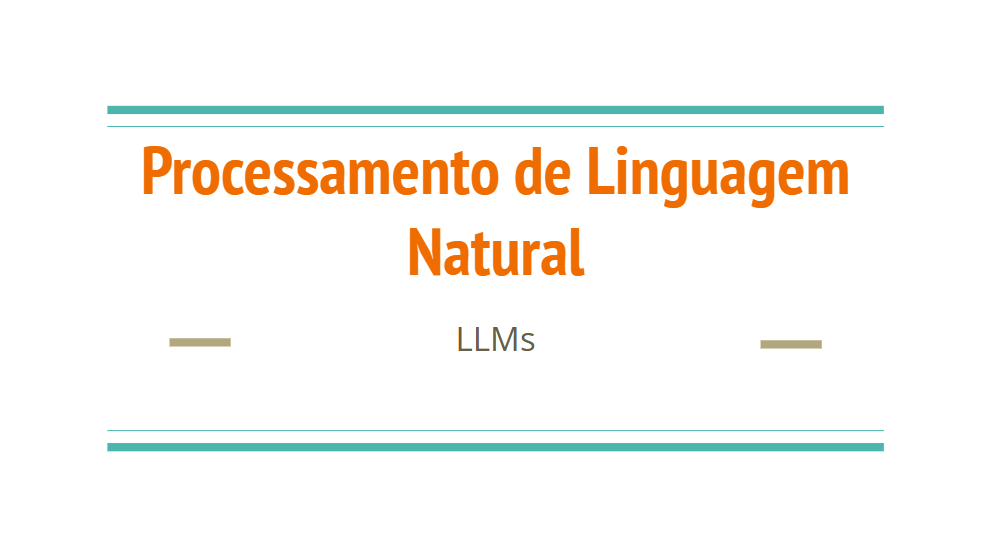

## Introdução


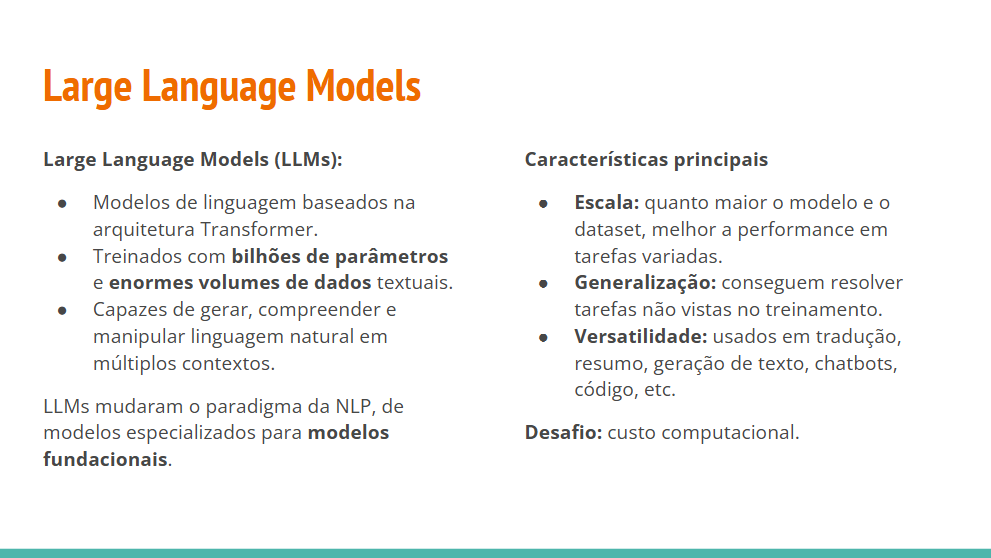

Os gráficos abaixo mostram a evolução dos modelos em termos do **número de parâmetros** ao longo do tempo. O primeiro mostra a evolução dos modelos até 2020 e o segundo até 2022.

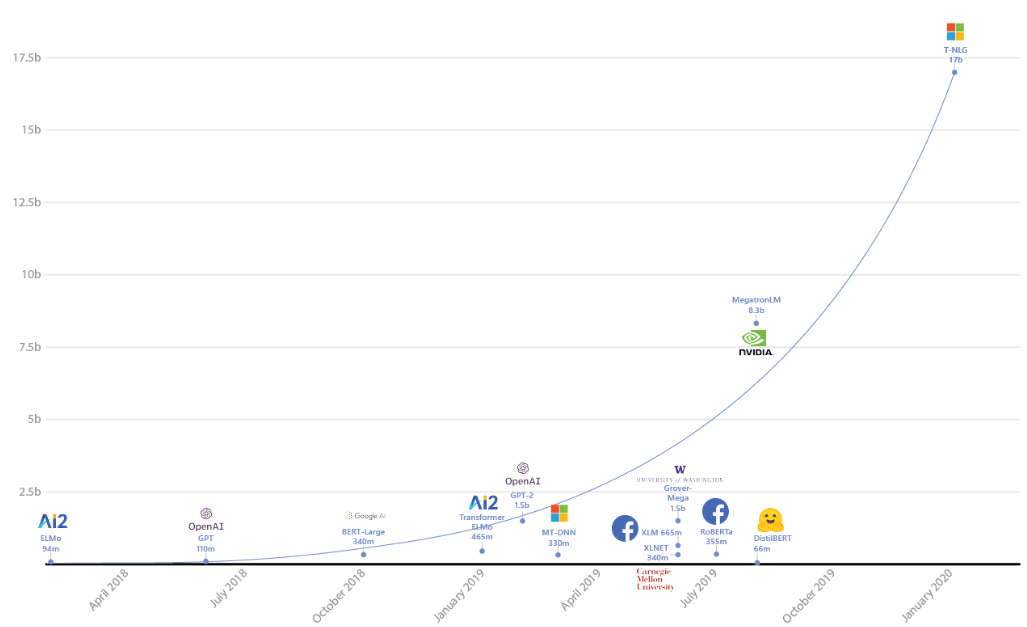

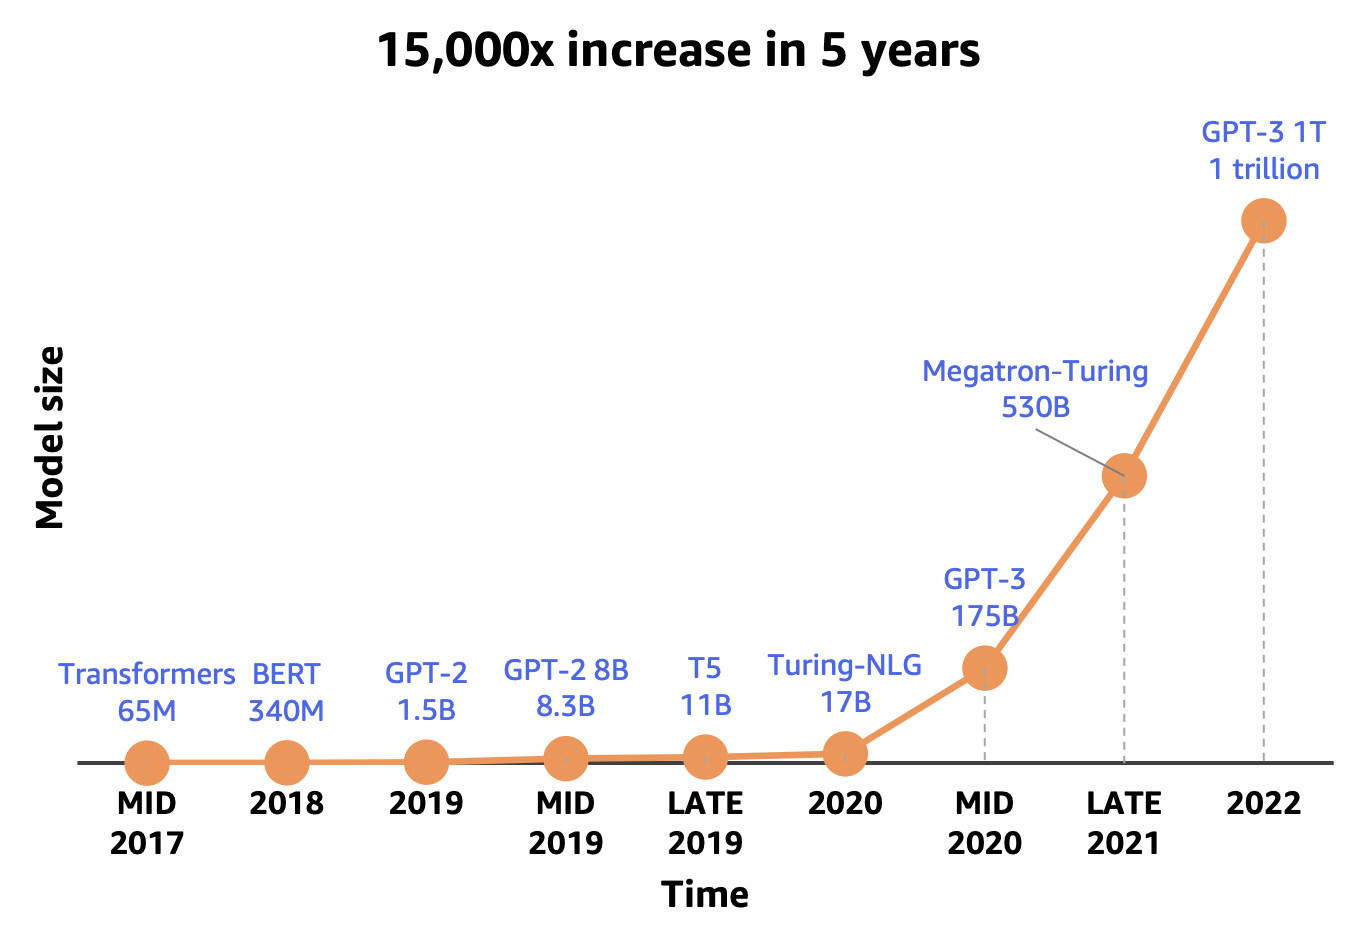

Paralelamente ao número de parâmetros, tem crescido também o tamanho dos **datasets** utilizados pelos modelos.

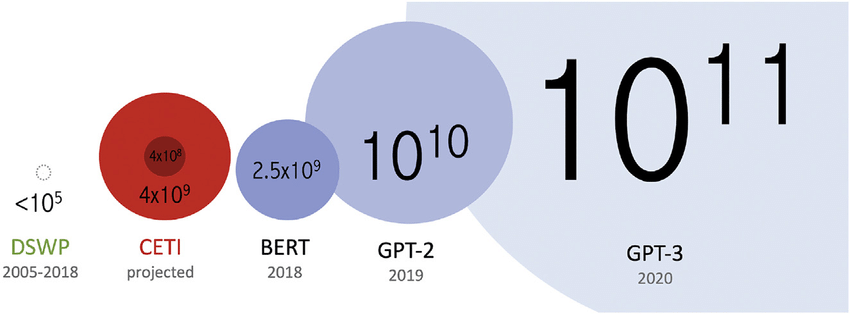

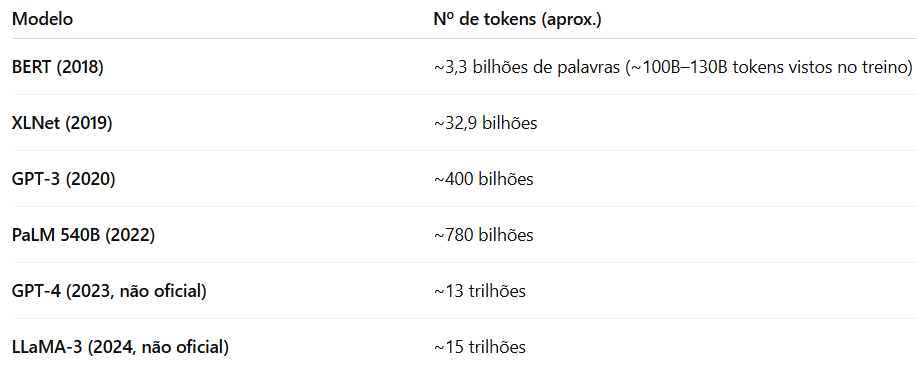

**Obs.:** Tabela obtida com o GPT5 (pode conter imprecisões).

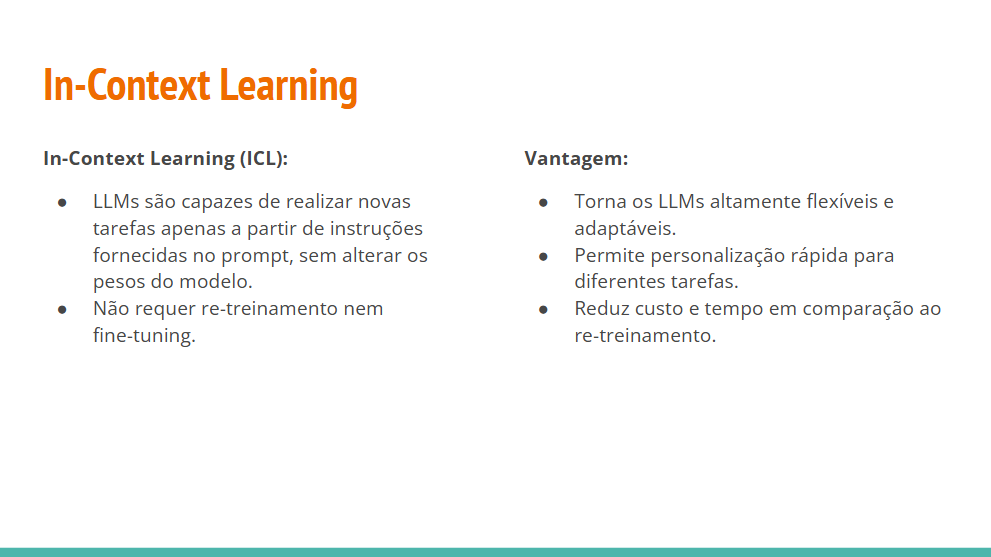

### Aplicação

Vamos testar as capacidades de aprendiza em contexto do `Llama-3.2-1B`.

**Tarefas:**

1. **Machine Translation.** Peça para o modelo traduzir a seguinte frase para o português:
      
   "I am studying natural language processing"


2. **Question Answering.** Escreva um prompt perguntando ao modelo: "Quem foi Albert Einstein?"

    Veja se o modelo responde de forma coerente.


3. **Text Generation.** Peça ao modelo para continuar a frase:

    "Era uma vez um cientista que descobriu..."

    Observe como o modelo completa a história.

Antes, porém, você precisará fazer algumas coisas:

1. Criar uma conta no HuggingFace.
2. Criar um token.
3. Solicitar acesso ao modelo.
4. Logar no HF pelo Colab.
5. Conferir autorização (Repositories permissions).

In [2]:
# Login no HF
login("<seu_token>")

In [3]:
# Use a pipeline as a high-level helper
pipe = pipeline("text-generation", model="meta-llama/Llama-3.2-1B")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Device set to use cuda:0


In [5]:
# Tradução
prompt = "Traduza para o português: I am studying natural language processing."

# Gerar texto
output = pipe(prompt, max_new_tokens=50)

print(output[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Traduza para o português: I am studying natural language processing. I would like to work on a project related to this topic. I have some good ideas. I am a very good programmer, and I can make a lot of code for you. I am a very good programmer and I can make a lot of


**Pergunta:** O que vocês acharam do resultado?

### Estrutura do modelo

Ao serem baixados pela API do Hugging Face, os modelos incluem informações completas sobre suas configurações, que podem ser acessada com o `AutoConfig`.

In [ ]:
config = AutoConfig.from_pretrained("meta-llama/Llama-3.2-1B")

print(config)

LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "dtype": "bfloat16",
  "eos_token_id": 128001,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 8192,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 16,
  "num_key_value_heads": 8,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_scaling": {
    "factor": 32.0,
    "high_freq_factor": 4.0,
    "low_freq_factor": 1.0,
    "original_max_position_embeddings": 8192,
    "rope_type": "llama3"
  },
  "rope_theta": 500000.0,
  "tie_word_embeddings": true,
  "transformers_version": "4.56.1",
  "use_cache": true,
  "vocab_size": 128256
}



**Pergunta:** Quais informações sobre o modelo vocês conseguem reconhecer?

## Chatbots

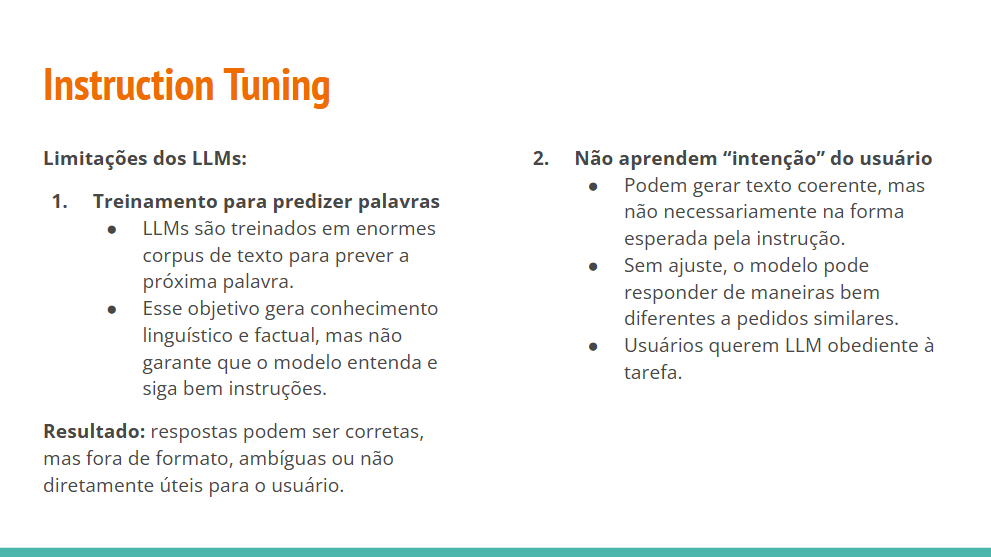

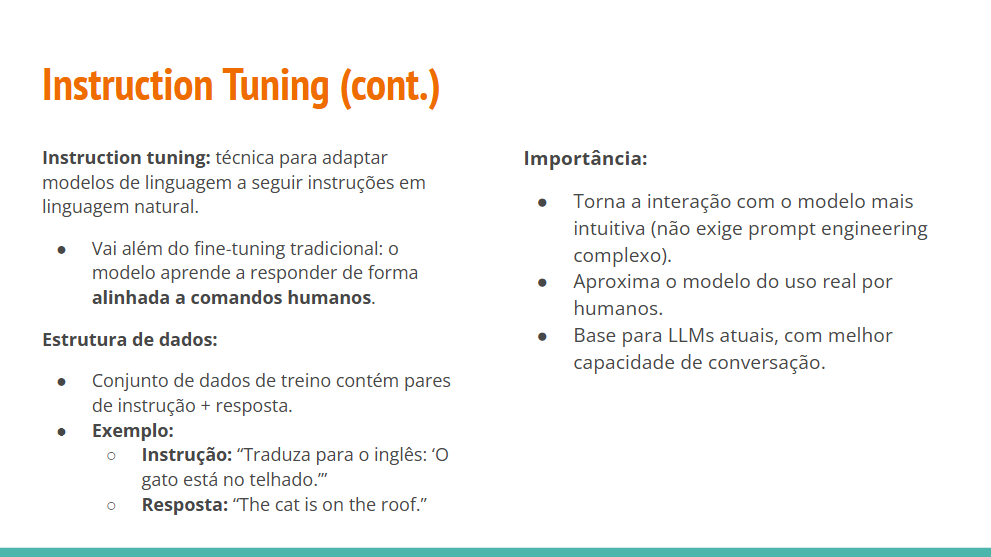

**Tarefa:** Execute as mesmas tarefas, mas agora com o modelo `Llama-3.2-1B-Instruct`.

In [ ]:
# Use a pipeline as a high-level helper
pipe = pipeline("text-generation", model="meta-llama/Llama-3.2-1B-Instruct")

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Device set to use cuda:0


In [4]:
# Tradução
prompt = "Traduza para o português: I am studying natural language processing."

# Gerar texto
output = pipe(prompt, max_new_tokens=50)

print(output[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Traduza para o português: I am studying natural language processing. I am trying to find the best way to learn the basic concepts of this field. I am looking for a book or a course that can help me understand the basics of this field. What is the best way to learn natural language processing?


**Pergunta:** Há alguma diferença nos resultados?

Outra customização importante em termos de chatbot é em relação a **instruções de sistemas** e de **usuários**.

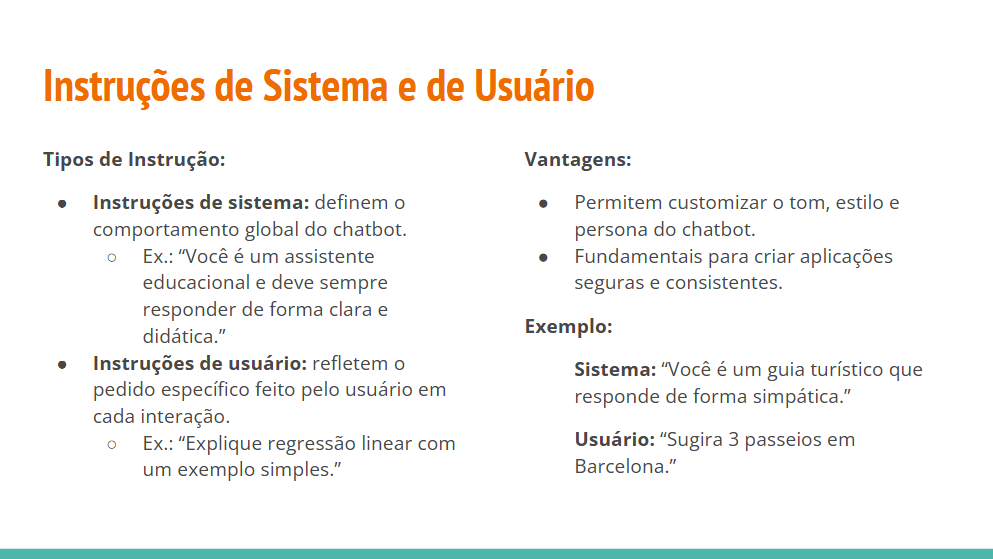

### Aplicação

Realize as mesmas tarefas de antes, mas agora utilizando o modelo `Qwen/Qwen2.5-3B-Instruct`. Configure as instruções de sistema e usuário.

In [6]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
prompt = "Explique o que é processamento de linguagem natural."

messages = [
    {"role": "system", "content": "Você é um chatbot que funciona como tutor de alunos do Instituto Mauá de Tecnologia. Forneça referências bibliográficas quando possível."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(response)

Processamento de Linguagem Natural (PLN) é uma área de pesquisa e desenvolvimento na computação que visa permitir que os sistemas de computador interajam com os humanos usando linguagem natural. Isso inclui a compreensão, geração, tradução, análise e gerenciamento de dados linguísticos.

A PLN envolve várias disciplinas, como linguística, inteligência artificial, computação, estatística e programação. O objetivo principal é fazer com que as máquinas possam entender, interpretar e produzir linguagem humana de forma eficaz.

Existem dois principais campos de estudo na PLN: o Processamento da Linguagem Natural de Entrada (NLP - Natural Language Processing) e o Processamento da Linguagem Natural de Saída (NLG - Natural Language Generation).

NLP de entrada é responsável por analisar e interpretar texto ou fala, enquanto NLP de saída se concentra em criar textos ou falas que sejam compreensíveis para o usuário.

Referências:

1. Jurafsky, D., & Martin, J. H. (2019). Speech and language proc

## Geração de Palavras

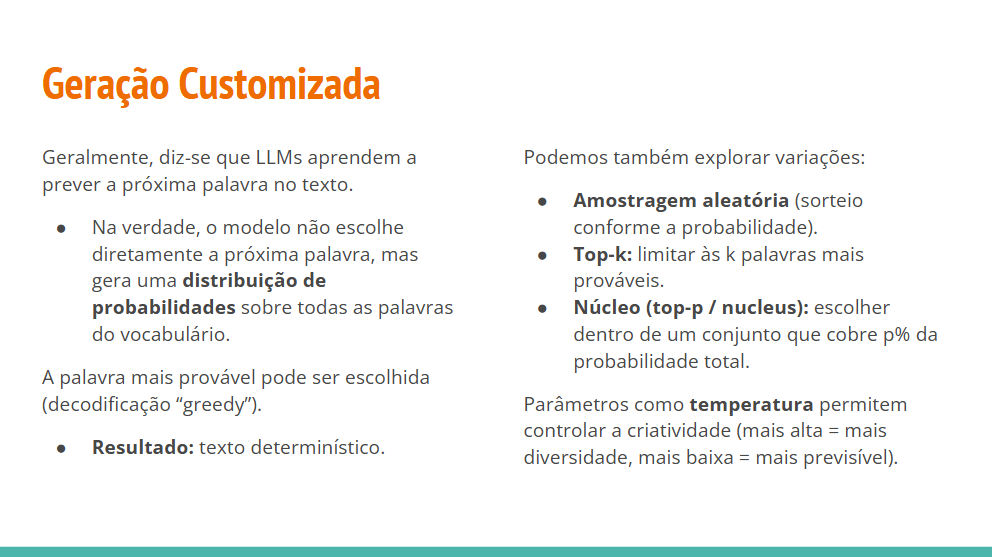

Com a biblioteca `transformers`, é possível alterar os parâmetros de geração de texto. Isso pode ser feito com o `pipeline` ou com `model.generate()`.

**Importante:** o `pipeline` permite apenas inferência.

**Aplicação:** Realize as mesmas tarefas com o Qwen, mas alterando os parâmetros de geração de texto. As modificações de parâmetros são feitas por meio da função `model.generate()`.

In [11]:
prompt = "Traduza para o português: I am studying natural language processing."

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=256,
    do_sample=True,         # garante sampling em vez de greedy
    temperature=2.3,        # controla aleatoriedade
    top_p=0.9,              # nucleus sampling
    top_k=50,               # top-k
    repetition_penalty=1.1  # penaliza repetições
)

generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(response)

Estou estudeiade Processamento de Linguagem Natural.


**Pergunta:** Que comportamento você pôde observar?

## Engenharia de Prompt

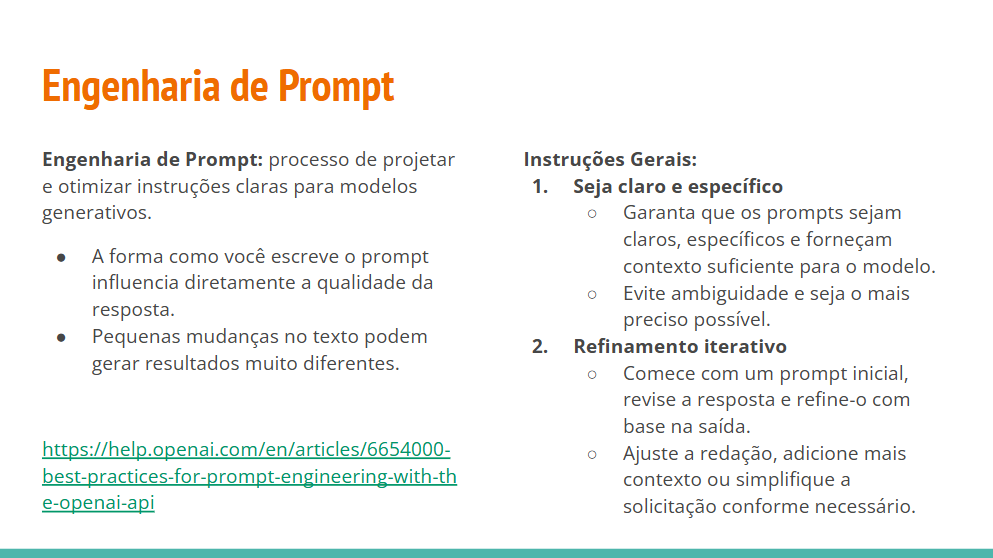

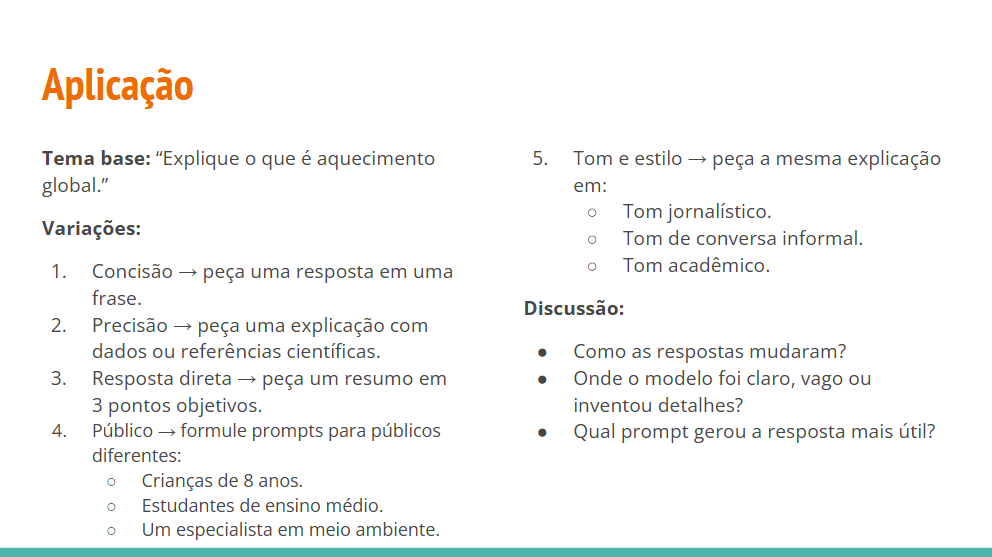

### Técnicas Avançadas

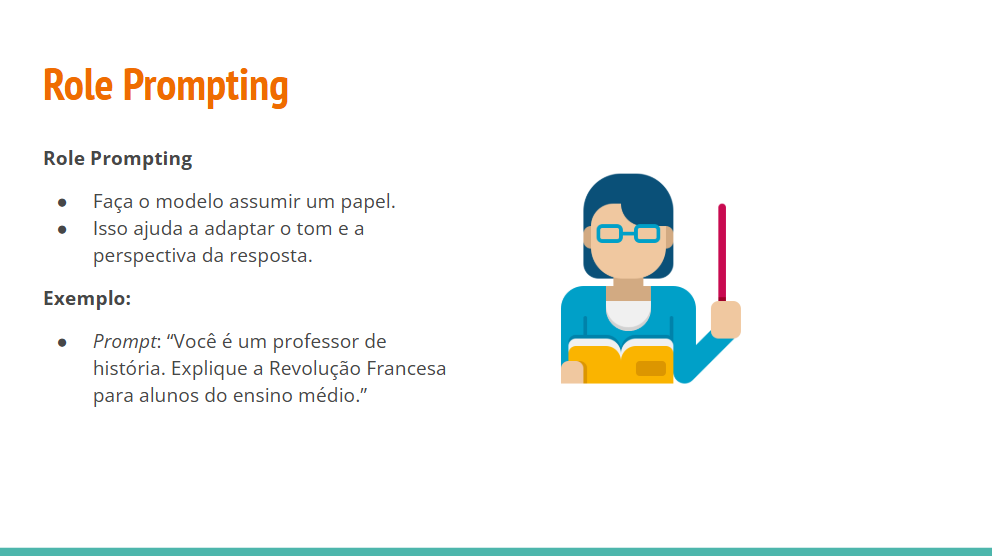

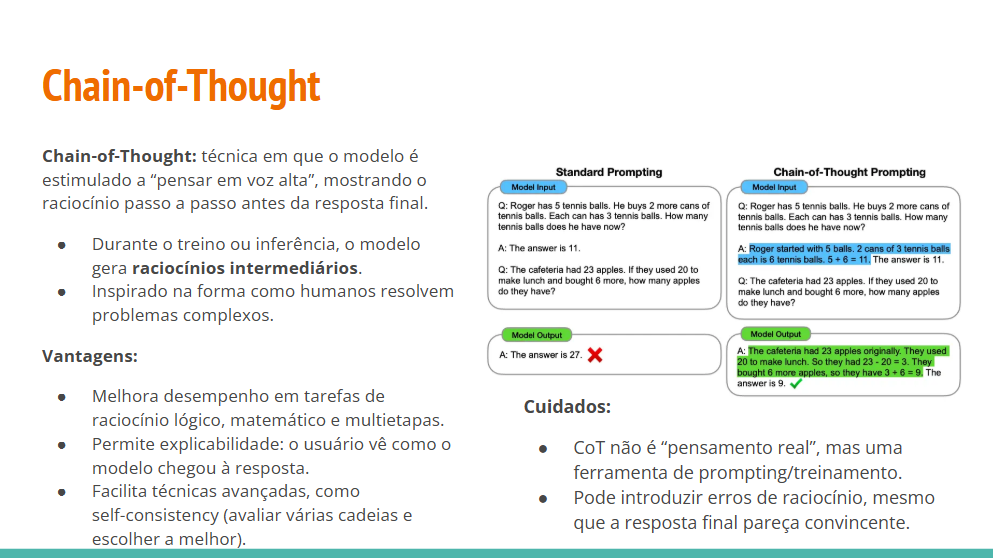

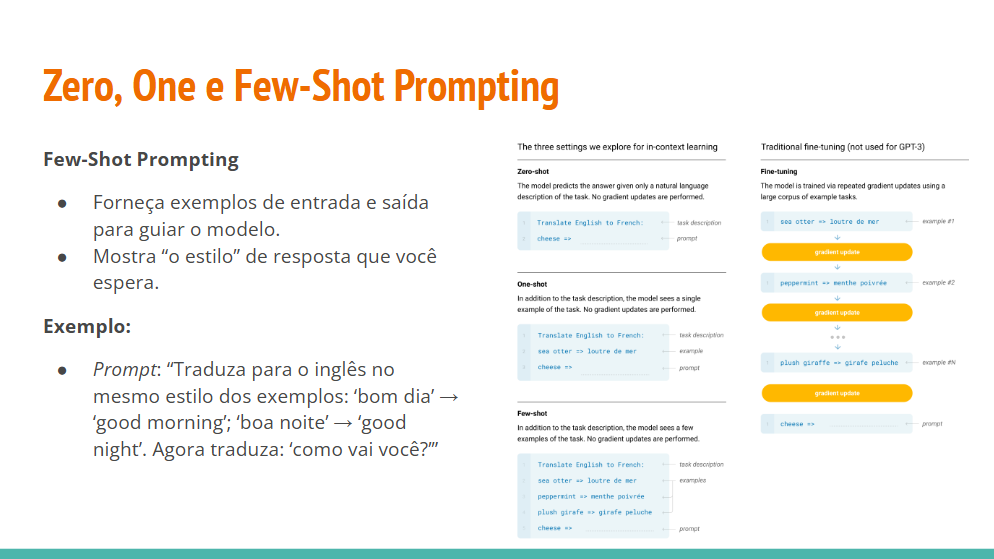

### Aplicação

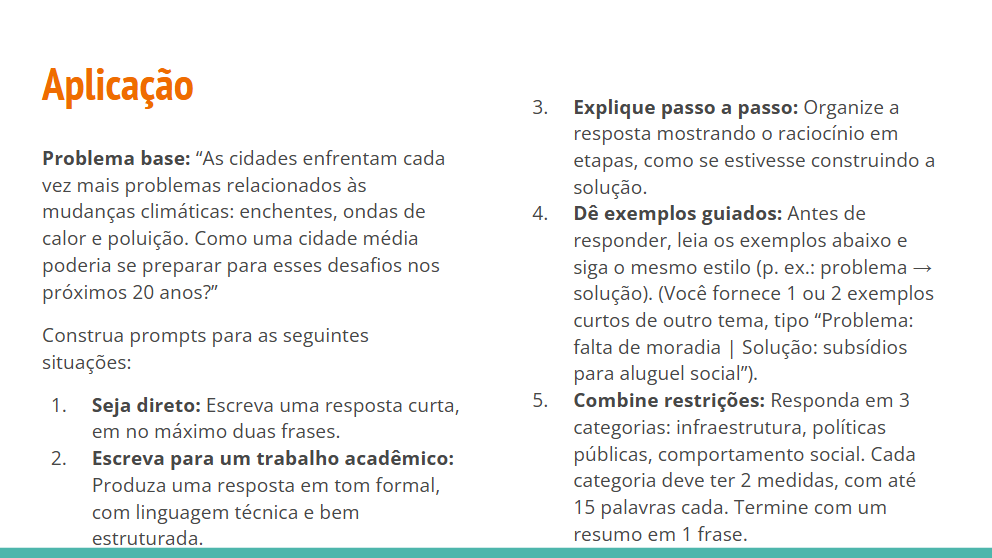

In [ ]:
# Resposta

## Memória

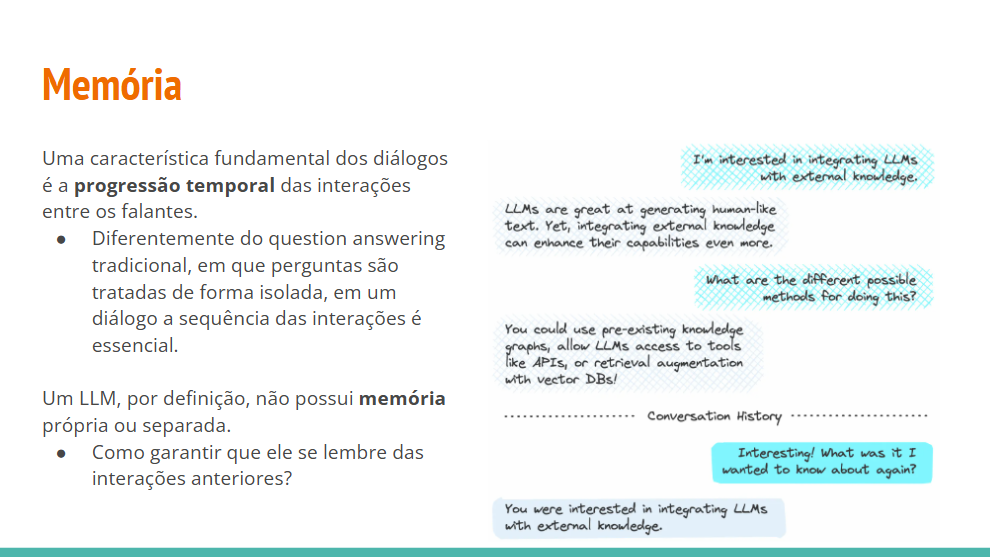

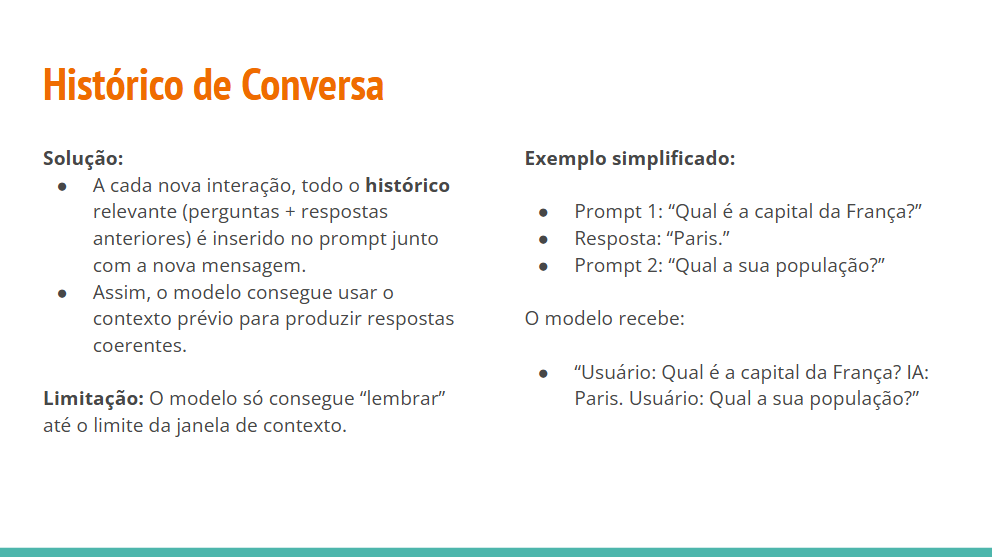

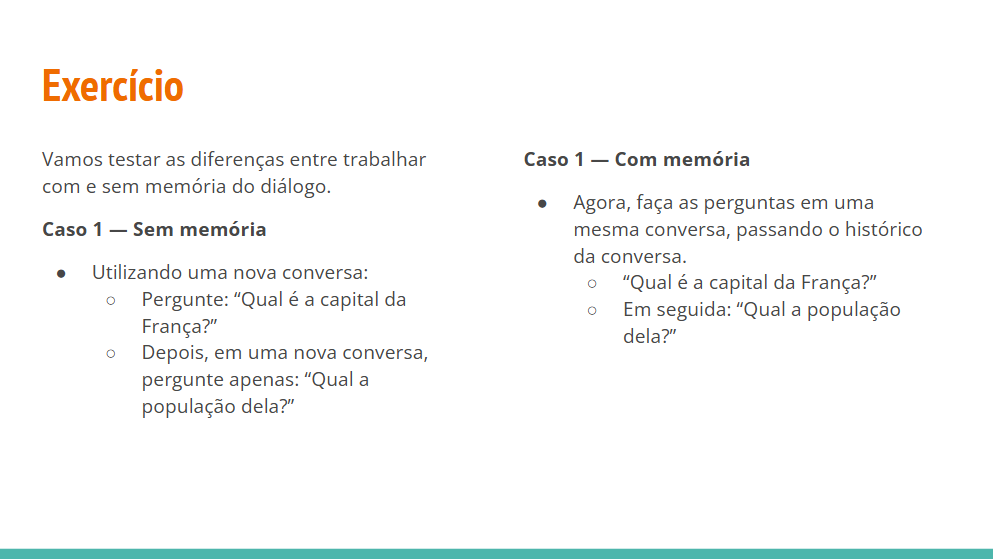

In [ ]:
# Sem memória
# Pergunta 1
prompt1 = "Qual a capital da França?"

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt1}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=256,
    do_sample=True,         # garante sampling em vez de greedy
    temperature=0.7,        # controla aleatoriedade
    top_p=0.9,              # nucleus sampling
    top_k=50,               # top-k
    repetition_penalty=1.1  # penaliza repetições
)

generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response1 = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print('Resposta 1:', response1)

# Pergunta 2
prompt2 = "Qual a sua população?"

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt2}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=256,
    do_sample=True,         # garante sampling em vez de greedy
    temperature=0.7,        # controla aleatoriedade
    top_p=0.9,              # nucleus sampling
    top_k=50,               # top-k
    repetition_penalty=1.1  # penaliza repetições
)

generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response2 = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print('Resposta 2:', response2)

Resposta 1: A capital da França é Paris.
Resposta 2: Como assistente de inteligência artificial, eu não tenho uma localização física ou população real. Eu estou disponível 24 horas por dia, todos os dias da semana, para ajudar com inúmeras tarefas e perguntas que você possa ter. Como posso ajudar você hoje?


In [ ]:
# Com memória
# Pergunta 1
prompt1 = "Qual a capital da França?"

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=256,
    do_sample=True,         # garante sampling em vez de greedy
    temperature=0.7,        # controla aleatoriedade
    top_p=0.9,              # nucleus sampling
    top_k=50,               # top-k
    repetition_penalty=1.1  # penaliza repetições
)

generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response1 = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print('Resposta 1:', response1)

# Pergunta 2
prompt2 = "Qual a sua população?"

full_prompt = 'User: ' + prompt1 + 'System: ' + response1 + 'User: ' + prompt2

print('Prompt completo:', full_prompt)

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": full_prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=256,
    do_sample=True,         # garante sampling em vez de greedy
    temperature=0.7,        # controla aleatoriedade
    top_p=0.9,              # nucleus sampling
    top_k=50,               # top-k
    repetition_penalty=1.1  # penaliza repetições
)

generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response2 = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print('Resposta 2:', response2)

Resposta 1: Estou estudando processamento de linguagem natural.
Prompt completo: User: Qual a capital da França?System: Estou estudando processamento de linguagem natural.User: Qual a sua população?
Resposta 2: A França tem uma grande população, mas não posso fornecer um número exato aqui diretamente, pois isso muda constantemente com novas estatísticas e censos. No entanto, para você ter uma ideia aproximada, a população atual da França é de mais ou menos 67 milhões de habitantes (este número está em constante mudança). Se precisar de informações mais recentes ou detalhes específicos, sugiro consultar fontes oficiais como o Instituto Nacional de Estatística e dos Recursos Humanos da França.


**Pergunta:** Quais limitações aparecem quando a conversa fica muito longa?

## Reinforcement Learning with Human Feedback

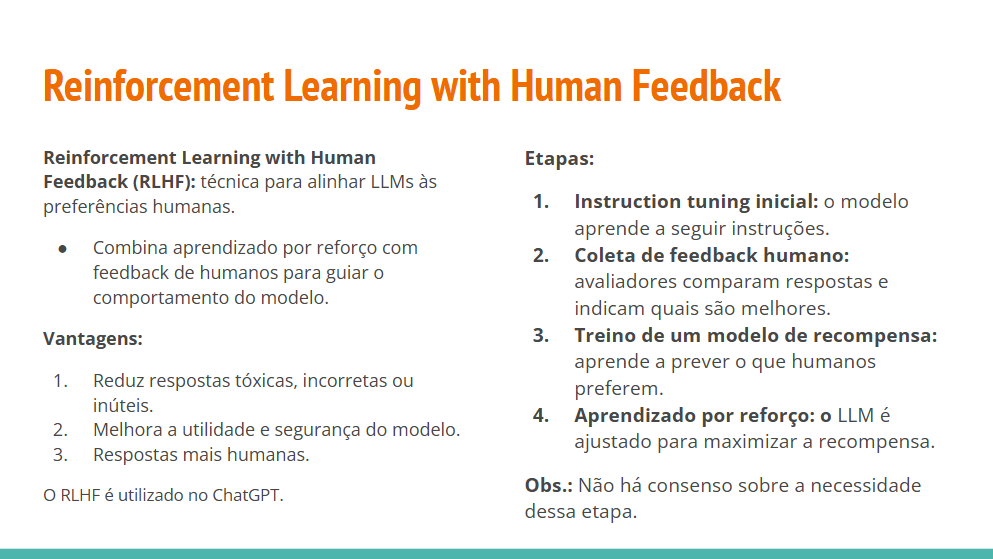

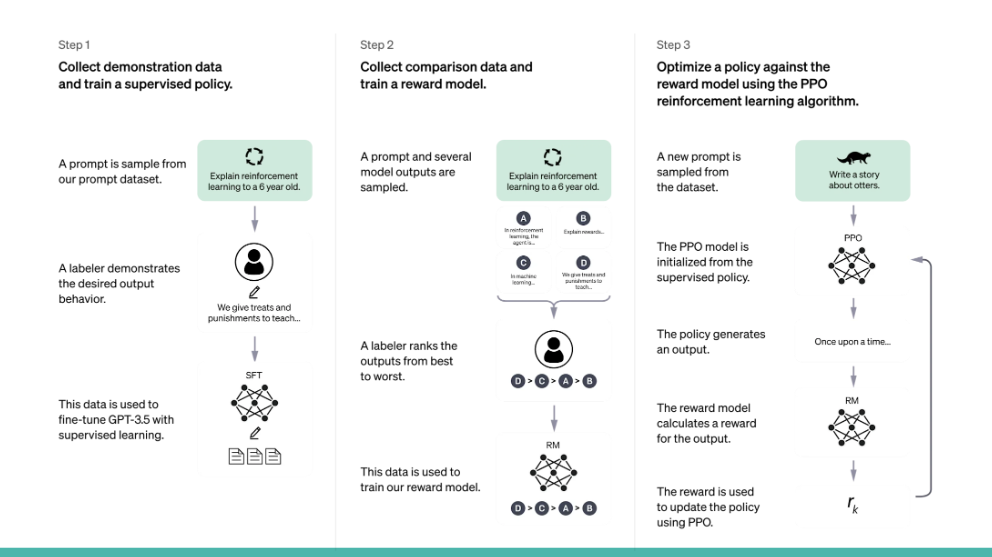

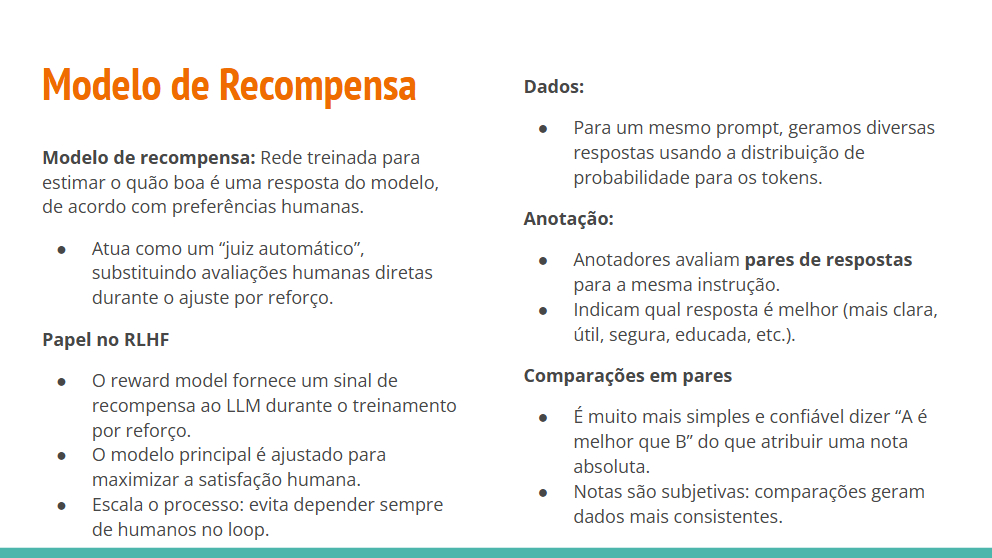

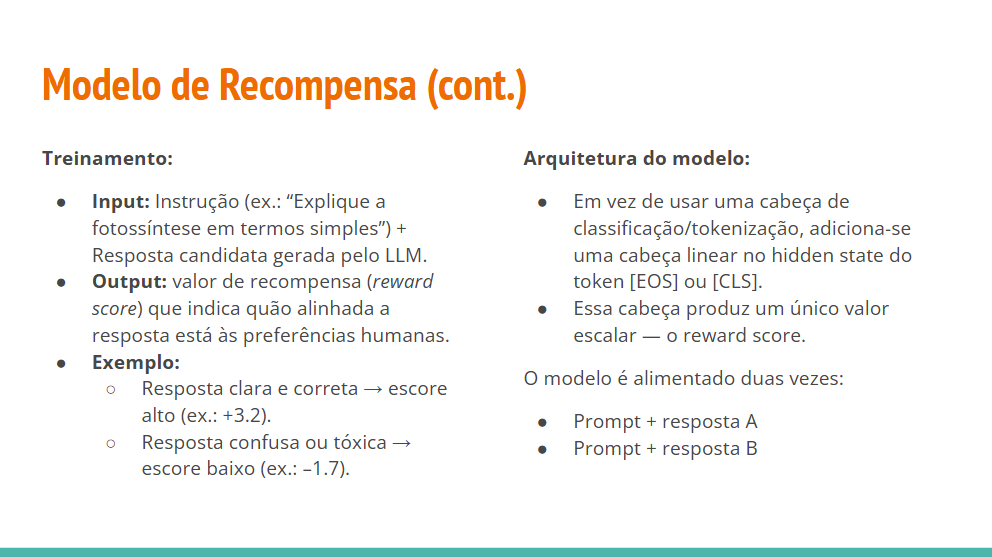

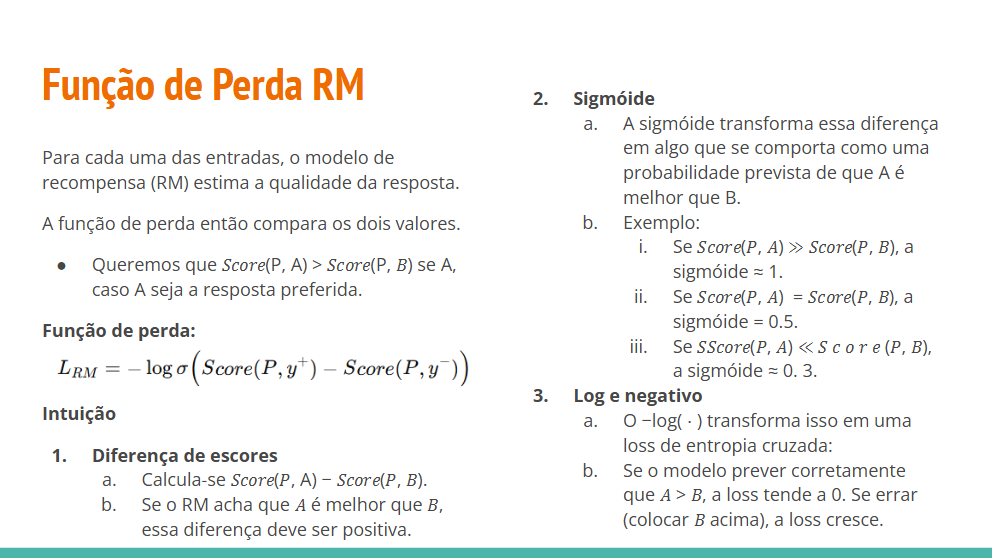

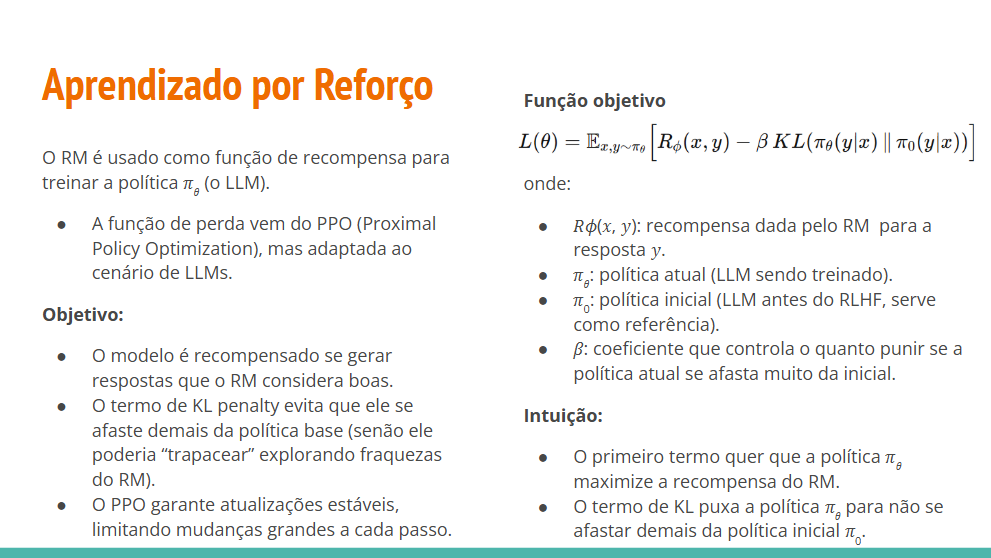

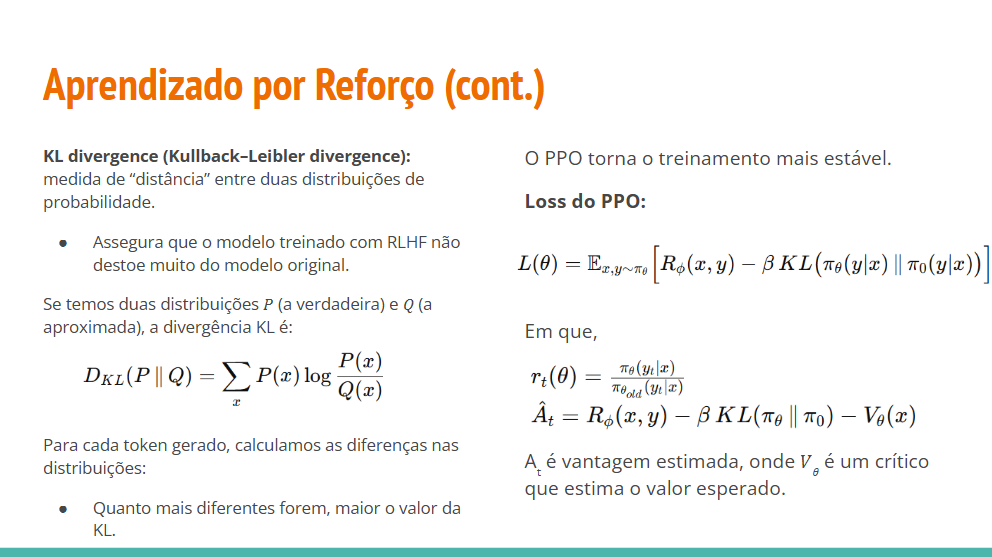

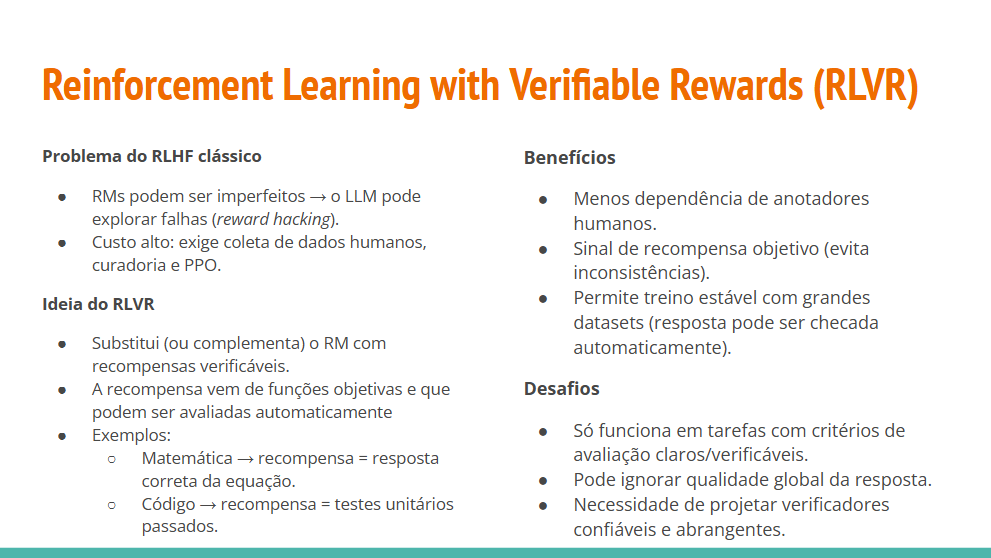